# 02 — Preprocessing & DataLoaders
### Diabetic Retinopathy Detection | APTOS 2019

**Goal:** Turn raw images into model-ready tensors.  
We will:
1. Set up `Config` — single source of truth for all hyperparameters
2. Apply per-class sampling to handle class imbalance
3. Define train / val augmentation pipelines
4. Build `RetinopathyDataset` and `DataLoader`
5. Verify a batch visually (augmented vs clean)
6. Save split CSVs for reproducibility

In [5]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms
from collections import Counter

# Add project root to path so we can import utils/
PROJECT_ROOT = os.getcwd()   # diabetic-retinopathy/
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utils.config  import Config
from utils.dataset import (
    set_seed, get_transforms,
    RetinopathyDataset, get_weighted_sampler, get_dataloaders
)

set_seed()
os.makedirs("outputs", exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"Config.IMG_SIZE      : {Config.IMG_SIZE}")
print(f"Config.BATCH_SIZE    : {Config.BATCH_SIZE}")
print(f"Config.MAX_PER_CLASS : {Config.MAX_PER_CLASS}")

Device : cpu
Config.IMG_SIZE      : 224
Config.BATCH_SIZE    : 32
Config.MAX_PER_CLASS : 500


In [6]:
df = pd.read_csv(Config.TRAIN_CSV)
print(f"Full dataset : {len(df)} images")
print("Original class distribution:")
print(df["diagnosis"].value_counts().sort_index().to_string())

# ── Per-class cap ─────────────────────────────────────────────
if Config.MAX_PER_CLASS is not None:
    df_sampled = (
        df.groupby("diagnosis", group_keys=False)
          .apply(lambda g: g.sample(
              min(len(g), Config.MAX_PER_CLASS),
              random_state=Config.SEED))
          .reset_index(drop=True)
    )
    print(f"\nSampled dataset : {len(df_sampled)} images ({Config.MAX_PER_CLASS}/class max)")
    print("Sampled class distribution:")
    print(df_sampled["diagnosis"].value_counts().sort_index().to_string())
else:
    df_sampled = df
    print("\nUsing full dataset (no sampling cap).")

Full dataset : 3662 images
Original class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295

Sampled dataset : 1858 images (500/class max)
Sampled class distribution:
diagnosis
0    500
1    370
2    500
3    193
4    295


---
## 2. Train / Validation Split

Train : 1486 images
Val   : 372 images



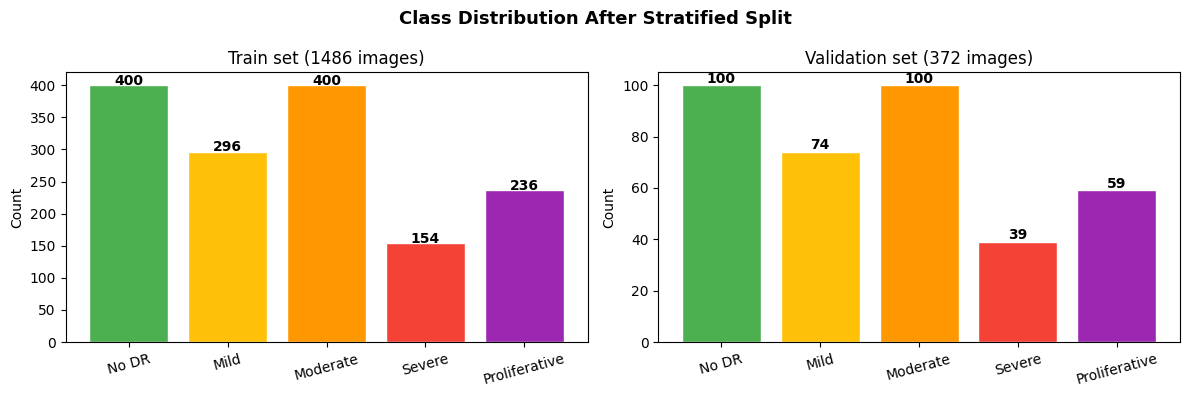

Saved: outputs/train_split.csv & val_split.csv


In [7]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_sampled,
    test_size=0.2,
    stratify=df_sampled["diagnosis"],
    random_state=Config.SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train : {len(train_df)} images")
print(f"Val   : {len(val_df)} images")
print()

# Verify stratification
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution After Stratified Split", fontsize=13, fontweight="bold")

for ax, split_df, title in zip(axes,
                                [train_df, val_df],
                                ["Train", "Validation"]):
    counts = split_df["diagnosis"].value_counts().sort_index()
    bars = ax.bar(Config.CLASS_NAMES, counts.values,
                  color=Config.CLASS_COLORS, edgecolor="white")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1, str(val),
                ha="center", fontsize=10, fontweight="bold")
    ax.set_title(f"{title} set ({len(split_df)} images)")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("outputs/02_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Save splits for reproducibility
train_df.to_csv("outputs/train_split.csv", index=False)
val_df.to_csv("outputs/val_split.csv",   index=False)
print("Saved: outputs/train_split.csv & val_split.csv")

---
## 3. Augmentation Pipeline

| Transform | Train | Val | Why |
|-----------|-------|-----|-----|
| Resize to 244×244 | ✓ | ✓ | VGG16 expects 224×224 |
| RandomCrop 224 | ✓ | ✗ | Slight position invariance |
| RandomHorizontalFlip | ✓ | ✗ | Retinas are symmetric |
| RandomVerticalFlip | ✓ | ✗ | Further symmetry |
| RandomRotation ±15° | ✓ | ✗ | Camera angle variation |
| ColorJitter | ✓ | ✗ | Lighting / device variation |
| Normalize (ImageNet) | ✓ | ✓ | Match VGG16 pretrain stats |

In [8]:
train_tf, val_tf = get_transforms()

print("Train transforms:")
print(train_tf)
print()
print("Val transforms:")
print(val_tf)

Train transforms:
Compose(
    Resize(size=(244, 244), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


---
## 4. Visualize Augmentations
Apply train transforms 6 times to the same image — shows the variety of augmentations.

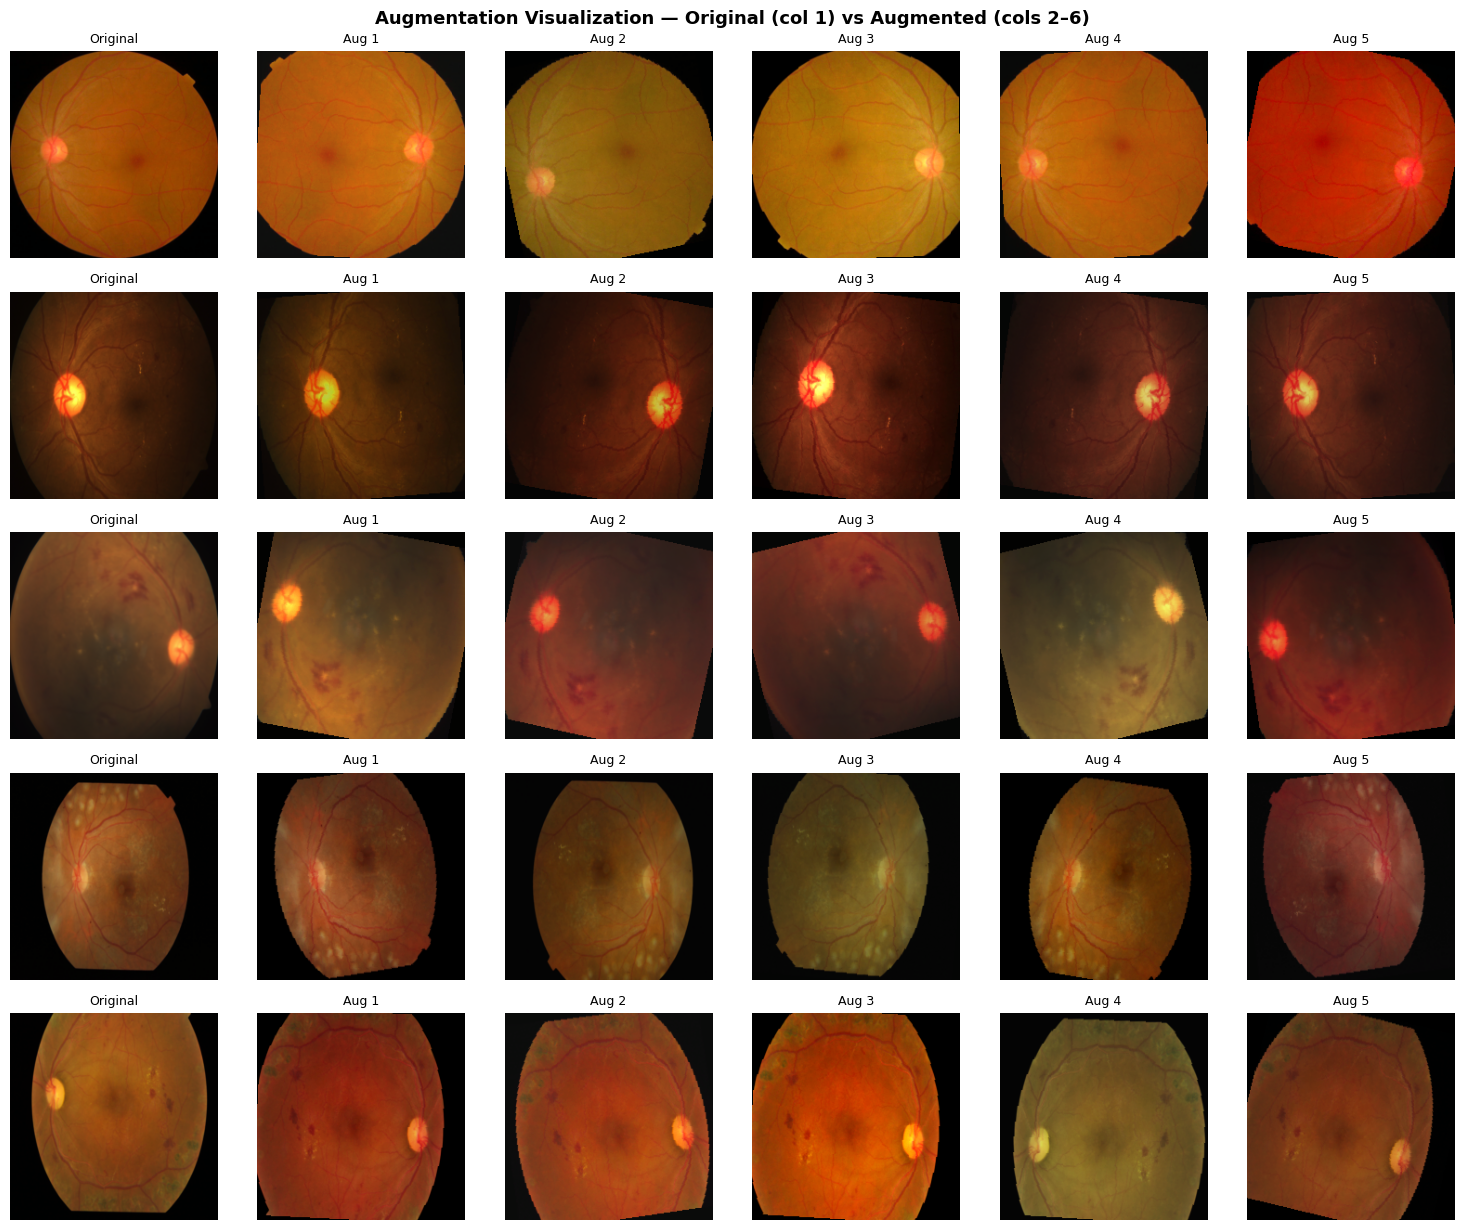

In [9]:
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(Config.MEAN, Config.STD)],
    std=[1/s for s in Config.STD]
)

# one image from each grade
sample_rows = [train_df[train_df["diagnosis"] == g].iloc[0] for g in range(5)]

N_AUG = 5   # augmented versions to show
fig, axes = plt.subplots(5, N_AUG + 1, figsize=((N_AUG + 1) * 2.5, 5 * 2.5))
fig.suptitle("Augmentation Visualization — Original (col 1) vs Augmented (cols 2–6)",
             fontsize=13, fontweight="bold")

for row_idx, sample_row in enumerate(sample_rows):
    img_path = os.path.join(Config.TRAIN_IMGS, sample_row["id_code"] + ".png")
    raw_img  = Image.open(img_path).convert("RGB")

    # Col 0 — original (val transform, no augmentation)
    ax = axes[row_idx][0]
    val_tensor = val_tf(raw_img)
    orig_display = inv_normalize(val_tensor).permute(1, 2, 0).numpy()
    orig_display = np.clip(orig_display, 0, 1)
    ax.imshow(orig_display)
    ax.set_title("Original", fontsize=9)
    ax.axis("off")
    if row_idx == 0 or True:
        ax.set_ylabel(
            f"Grade {sample_row['diagnosis']}\n{Config.CLASS_NAMES[sample_row['diagnosis']]}",
            fontsize=9, fontweight="bold",
            color=Config.CLASS_COLORS[sample_row["diagnosis"]]
        )
        ax.yaxis.set_visible(True)
        ax.tick_params(left=False, labelleft=True)

    # Cols 1–N_AUG — augmented versions
    for col in range(1, N_AUG + 1):
        aug_tensor  = train_tf(raw_img)
        aug_display = inv_normalize(aug_tensor).permute(1, 2, 0).numpy()
        aug_display = np.clip(aug_display, 0, 1)
        ax = axes[row_idx][col]
        ax.imshow(aug_display)
        ax.set_title(f"Aug {col}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/02_augmentations.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 5. Build DataLoaders

In [10]:
from torch.utils.data import DataLoader

train_dataset = RetinopathyDataset(train_df, Config.TRAIN_IMGS, train_tf)
val_dataset   = RetinopathyDataset(val_df,   Config.TRAIN_IMGS, val_tf)

sampler = get_weighted_sampler(train_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    sampler=sampler,
    num_workers=Config.NUM_WORKERS,
    pin_memory=(DEVICE == "cuda")
)
val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=(DEVICE == "cuda")
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Train images  : {len(train_dataset)}")
print(f"Val images    : {len(val_dataset)}")

Train batches : 47
Val batches   : 12
Train images  : 1486
Val images    : 372


---
## 6. Verify a Batch
Fetch one batch and confirm shapes, dtype, and value range.

In [11]:
images, labels = next(iter(train_loader))

print(f"Batch images shape : {images.shape}")
print(f"Batch labels shape : {labels.shape}")
print(f"Image dtype        : {images.dtype}")
print(f"Pixel min / max    : {images.min():.3f} / {images.max():.3f}")
print(f"Labels in batch    : {sorted(labels.tolist())}")
print()

# Expected: torch.Size([32, 3, 224, 224]) | dtype float32 | range roughly [-2.1, 2.6]

Batch images shape : torch.Size([32, 3, 224, 224])
Batch labels shape : torch.Size([32])
Image dtype        : torch.float32
Pixel min / max    : -2.118 / 2.429
Labels in batch    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4]



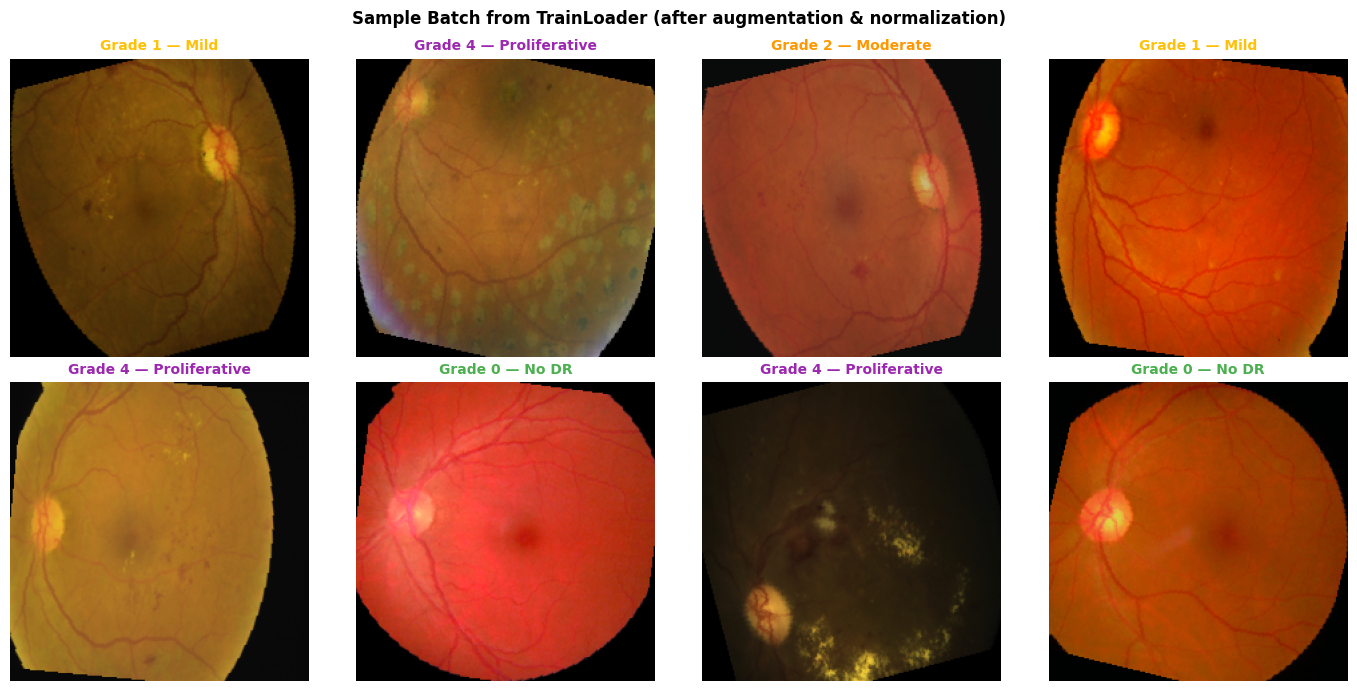

In [12]:
# Visualize 8 images from the batch with their labels
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Batch from TrainLoader (after augmentation & normalization)",
             fontsize=12, fontweight="bold")

for i, ax in enumerate(axes.flatten()):
    img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    label = labels[i].item()
    ax.imshow(img)
    ax.set_title(
        f"Grade {label} — {Config.CLASS_NAMES[label]}",
        color=Config.CLASS_COLORS[label], fontsize=10, fontweight="bold"
    )
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/02_sample_batch.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. WeightedRandomSampler — Verify Balance
Confirm the sampler produces balanced batches across classes.

In [14]:
# Collect labels from 10 batches and check distribution
N_BATCHES  = 10
all_labels = []

for i, (_, lbls) in enumerate(train_loader):
    all_labels.extend(lbls.tolist())
    if i + 1 >= N_BATCHES:
        break

sampled_counts = Counter(all_labels)

print(f"Label distribution over {N_BATCHES} batches ({len(all_labels)} images):")
for grade, name in enumerate(Config.CLASS_NAMES):
    cnt = sampled_counts.get(grade, 0)
    pct = cnt / len(all_labels) * 100
    bar = "█" * int(pct / 2)
    print(f"  Grade {grade} ({name:<15}): {cnt:>4}  ({pct:5.1f}%)  {bar}")

Label distribution over 10 batches (320 images):
  Grade 0 (No DR          ):   73  ( 22.8%)  ███████████
  Grade 1 (Mild           ):   62  ( 19.4%)  █████████
  Grade 2 (Moderate       ):   59  ( 18.4%)  █████████
  Grade 3 (Severe         ):   55  ( 17.2%)  ████████
  Grade 4 (Proliferative  ):   71  ( 22.2%)  ███████████


## 8. Summary

In [16]:
print("=" * 55)
print("  PREPROCESSING SUMMARY")
print("=" * 55)
print(f"  Total images (sampled) : {len(df_sampled)}")
print(f"  Train / Val split      : {len(train_df)} / {len(val_df)}")
print(f"  Image size             : {Config.IMG_SIZE}×{Config.IMG_SIZE}")
print(f"  Batch size             : {Config.BATCH_SIZE}")
print(f"  Augmentations (train)  : flip, rotate, crop, colorjitter")
print(f"  Imbalance handling     : WeightedRandomSampler")
print(f"  Normalization          : ImageNet mean/std")
print()
print("  Saved outputs:")
print("    outputs/train_split.csv")
print("    outputs/val_split.csv")
print("    outputs/02_split_distribution.png")
print("    outputs/02_augmentations.png")
print("    outputs/02_sample_batch.png")
print("=" * 55)

  PREPROCESSING SUMMARY
  Total images (sampled) : 1858
  Train / Val split      : 1486 / 372
  Image size             : 224×224
  Batch size             : 32
  Augmentations (train)  : flip, rotate, crop, colorjitter
  Imbalance handling     : WeightedRandomSampler
  Normalization          : ImageNet mean/std

  Saved outputs:
    outputs/train_split.csv
    outputs/val_split.csv
    outputs/02_split_distribution.png
    outputs/02_augmentations.png
    outputs/02_sample_batch.png
